# **Pre-Trained Model 1 - Efficient Net B0**

EfficientNetB0 was selected as the first pretrained architecture for the modelling phase. <br>


### **Why EfficientNet?**

EfficientNet is a CNN (convolutional neural network) built upon the concept of *compound scaling* — jointly scaling network depth, width and resolution via a fixed coefficient, rather than scaling any one dimension in isolation. This yields significantly better accuracy-per-parameter than other architectures.

### **Why B0 specifically?**

B0 is the baseline of the EfficientNet family (φ = 0). With only approximatelly 5M parameters it is the lightest variant, balacing **speed and accuracy**, making it ideal for a constrained medical dataset (~11,000 images). We believe that a heavier variant (B4–B7) would risk overfitting without substantially more data or aggressive regularisation. Therefore, B0 sits at the **optimal point on the bias–variance trade-off for this task**.

#### Moreover, we took into consideration even more specific dataset characteristics for these choice:
- **Suitability for dermoscopy**: Dermoscopic classification relies on fine-grained texture and colour pattern recognition (such as, atypical pigment networks, regression structures and vascular patterns). EfficientNet's depthwise separable convolutions and MBConv blocks are effective at capturing both local texture detail and global spatial context;
- **Transfer learning rationale**: ImageNet pre-training provides a rich, low-level feature initialisation (edges, textures, blobs) that are important for these medical images. Fine-tuning only the top layers in phase 1 prevents catastrophic forgetting of these representations and lets the new classification head converge stably.


### Imports

In [1]:
import tensorflow as tf
#prevent TF from grabbing all GPU memory at once
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
import os
import sys
import keras.applications
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from keras.applications.efficientnet import preprocess_input


if os.getcwd().endswith('models'):
    os.chdir('..')
    
from utils.utils_model import *
from utils.utils_augmentation import *
from utils.utils_preproc import *

In [3]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
print("TF built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available to TF:", tf.test.is_gpu_available())  # deprecated but still works

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU available to TF: True


### **Data** Configuration

In [4]:
# Load label mapping first — everything else depends on it
with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

N_CLASSES  = len(label2idx)
BATCH_SIZE = 32

train_df = pd.read_csv('data/augmented_metadata.csv')
val_df   = pd.read_csv('data/val_split.csv')
test_df  = pd.read_csv('data/test_split.csv')

# Normalise column names and encode labels for all splits
for df in [train_df, val_df, test_df]:
    if 'cleaned_path' in df.columns and 'image_path' in df.columns:
        df.drop(columns=['image_path'], inplace=True)
    df.rename(columns={'cleaned_path': 'image_path'}, inplace=True)
    df['dx_encoded'] = df['dx'].map(label2idx).astype(int)

# Build datasets
train_ds = make_dataset(train_df, shuffle=True, repeat=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE
class_weights_dict = make_class_weights(train_df)

In [5]:
print(f"Steps per epoch: {STEPS_PER_EPOCH}")
print(f"Class weights: {class_weights_dict}")

Steps per epoch: 390
Class weights: {0: 1.4830327479829142, 1: 1.2374022374022373, 2: 0.8576231645395911, 3: 2.2044091710758376, 4: 0.886579656688892, 5: 0.42452958358807147, 6: 2.412934362934363}


### **Model** Configuration

In [6]:
UNFREEZE_FROM_B = -30   # unfreeze last 30 layers of EfficientNetB0

def build_efficientnet():
    base = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling=None
        
    )
    base.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)

    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.4)(x)
    x = keras.layers.Dense(256, activation="relu")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(N_CLASSES)(x)
    return keras.Model(inputs, outputs, name="efficientnet_b0")

Model: "efficientnet_b0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                     

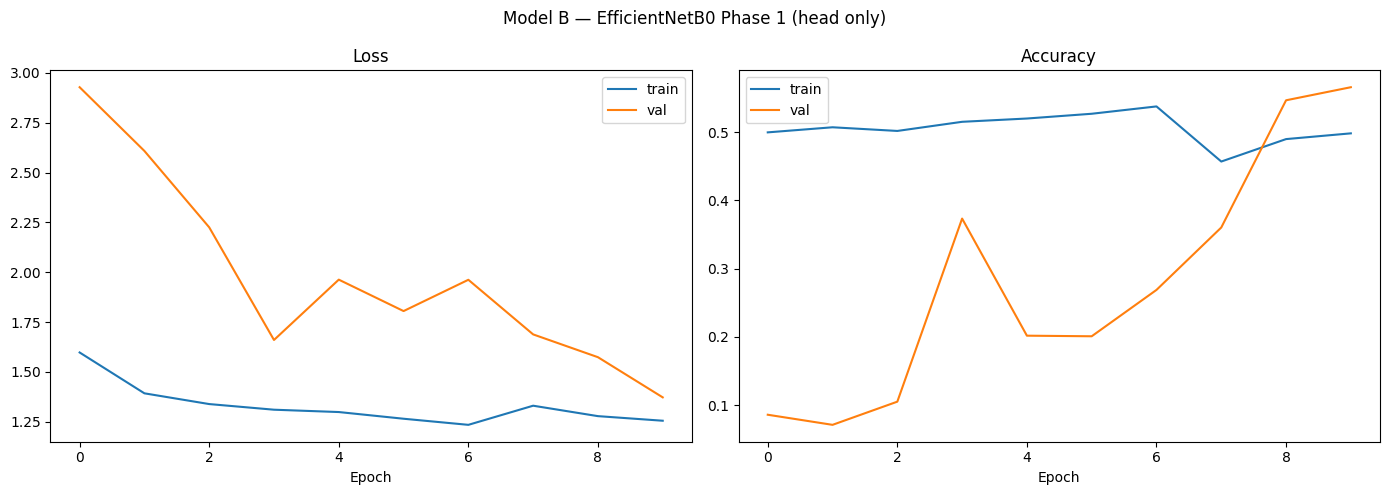

In [7]:
# phase 1: head only
model_pt1 = build_efficientnet() # Model Pre-Trained 1
model_pt1.summary()

model_pt1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)]
)
history1_pt1 = model_pt1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("checkpoints/model_b_phase1.weights.h5",
                            patience_es=6, patience_lr=3)

)

plot_history(history1_pt1, "Model B — EfficientNetB0 Phase 1 (head only)")

Epoch 1/30
390/390 [==============================] - ETA: 0s - loss: 1.2559 - accuracy: 0.4599 - balanced_accuracy: 0.5421
Epoch 1: val_loss improved from inf to 1.47062, saving model to checkpoints\model_b_best.weights.h5
390/390 [==============================] - 65s 131ms/step - loss: 1.2559 - accuracy: 0.4599 - balanced_accuracy: 0.5421 - val_loss: 1.4706 - val_accuracy: 0.6440 - val_balanced_accuracy: 0.3775 - lr: 1.0000e-05
Epoch 2/30
390/390 [==============================] - ETA: 0s - loss: 1.2221 - accuracy: 0.4839 - balanced_accuracy: 0.5644
Epoch 2: val_loss improved from 1.47062 to 1.44491, saving model to checkpoints\model_b_best.weights.h5
390/390 [==============================] - 49s 126ms/step - loss: 1.2221 - accuracy: 0.4839 - balanced_accuracy: 0.5644 - val_loss: 1.4449 - val_accuracy: 0.6571 - val_balanced_accuracy: 0.3936 - lr: 1.0000e-05
Epoch 3/30
390/390 [==============================] - ETA: 0s - loss: 1.1998 - accuracy: 0.4904 - balanced_accuracy: 0.5713
Ep

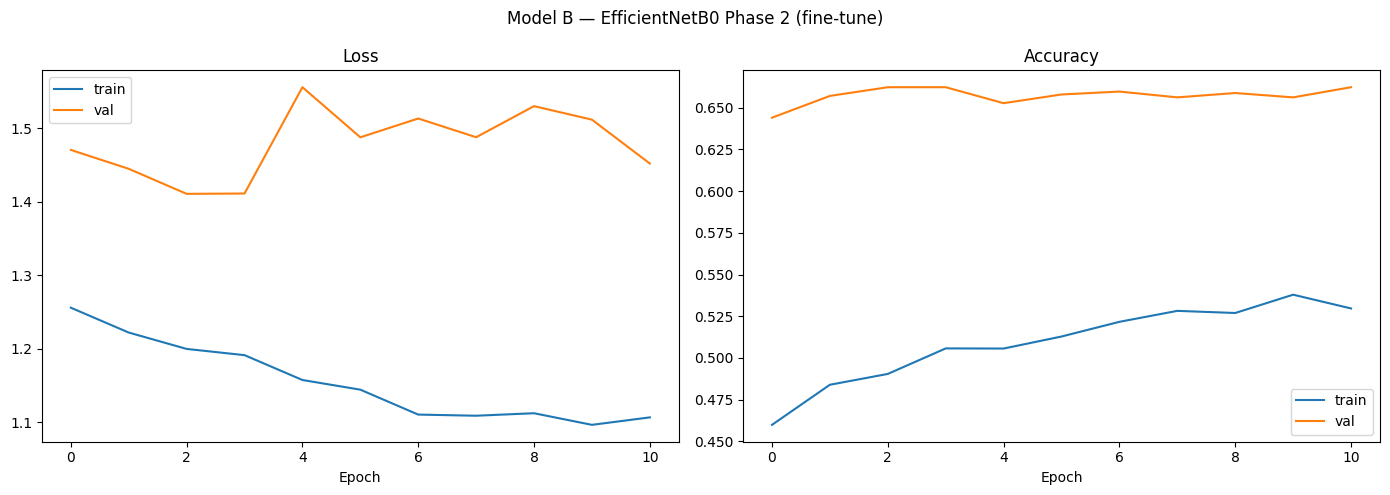


  Model B — EfficientNetB0 — classification report
              precision    recall  f1-score   support

       akiec       0.28      0.67      0.40        33
         bcc       0.62      0.18      0.28        55
         bkl       1.00      0.01      0.03       140
          df       0.16      0.36      0.22        11
         mel       0.33      0.03      0.05       137
          nv       0.75      0.96      0.84       765
        vasc       0.32      1.00      0.48        13

    accuracy                           0.68      1154
   macro avg       0.49      0.46      0.33      1154
weighted avg       0.70      0.68      0.60      1154

  *** Melanoma recall: 0.029 ***  (clinical priority metric)


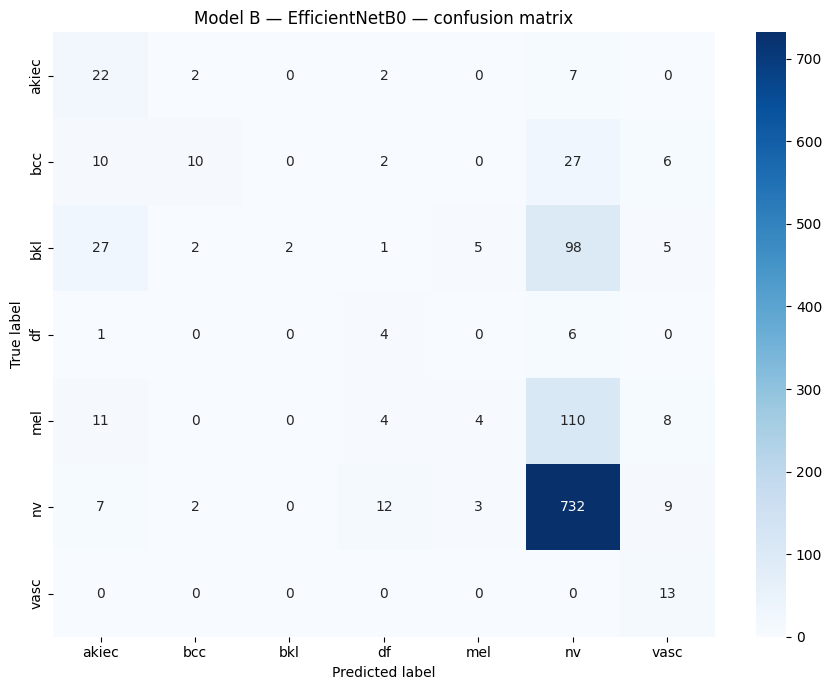


  Macro AUC-ROC: 0.9117


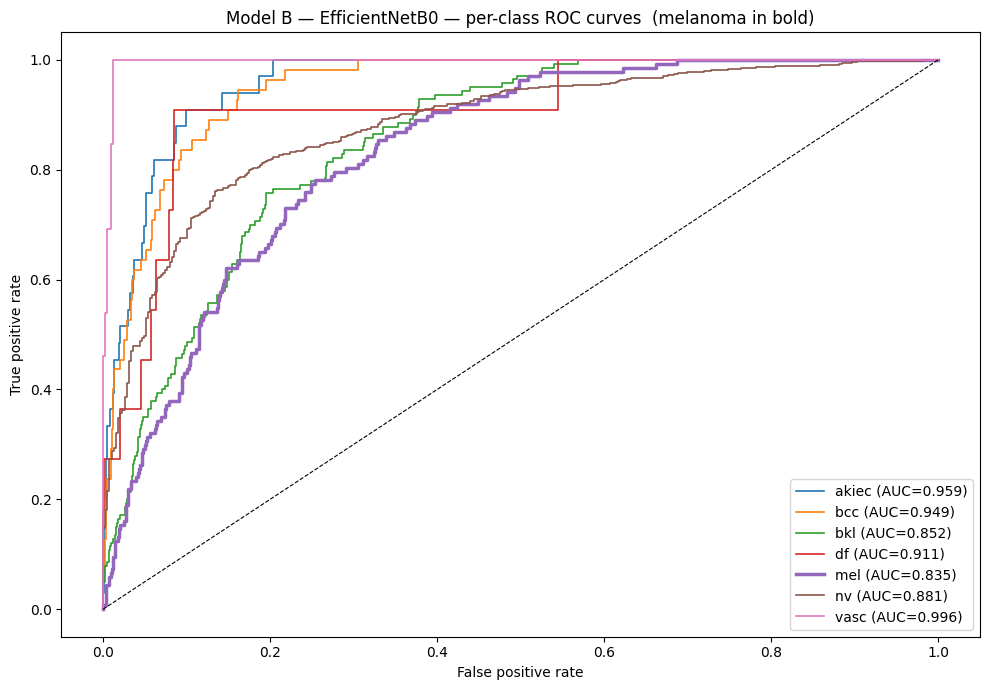

In [8]:
# Phase 2: Fine-tune top layers
base_b = model_pt1.get_layer('efficientnetb0')
base_b.trainable = True

for layer in base_b.layers[:UNFREEZE_FROM_B]:
    layer.trainable = False

model_pt1.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)]
)


history2_b0 = model_pt1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("checkpoints/model_b_best.weights.h5",
                        patience_es=8, patience_lr=4)

)

plot_history(history2_b0, "Model B — EfficientNetB0 Phase 2 (fine-tune)")
results_b = evaluate_model(model_pt1, test_ds, label2idx, "Model B — EfficientNetB0")
